In [34]:
pip install scipy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


## FDM Simulation

In [5]:
import numpy as np
from scipy.sparse.linalg import spsolve
import time

class FreezingSoilFDM:
    """1D finite difference forward model for soil freezing/thawing processes (simulation only, no plotting)"""
    def __init__(self, params):
        # ----- Physical parameters -----
        self.L = params['L']            # Latent heat of phase change (MJ/m³)
        self.C_i = params['C_i']       # Specific heat of ice (MJ/(m³·K))
        self.C_l = params['C_l']       # Specific heat of liquid water (MJ/(m³·K))
        self.C_f = params['C_f']       # Specific heat of soil skeleton (MJ/(m³·K))
        self.lambda_i = params['lambda_i']  # Thermal conductivity of ice (MJ/(day·m·K))
        self.lambda_l = params['lambda_l']  # Thermal conductivity of liquid water
        self.lambda_f = params['lambda_f']  # Thermal conductivity of soil skeleton
        self.eta = params['eta']        # Porosity
        self.b = params['b']            # Parameter for unfrozen water content curve
        self.T_nabla = params['T_nabla']# Freezing point depression onset (°C)

        # ----- Numerical parameters (set during initialization) -----
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None
        self.x = None
        self.T_field = None
        self.theta_old = None

    # ---------- Constitutive relations ----------
    def pore_water_content(self, T):
        """Pore liquid water fraction φ(T) (based on power-law empirical formula)"""
        T_safe = np.where(T == 0, 1e-6, T)
        return np.where(T >= self.T_nabla,
                       1.0,
                       np.abs(self.T_nabla)**self.b * np.abs(T_safe)**(-self.b))

    def unfrozen_water_content(self, T):
        """Volumetric unfrozen water content θ = η·φ(T)"""
        phi = self.pore_water_content(T)
        return self.eta * phi

    def effective_heat_capacity(self, T):
        """Effective volumetric heat capacity C_eff (MJ/(m³·K))"""
        phi = self.pore_water_content(T)
        return (1 - self.eta) * self.C_f + self.eta * (phi * self.C_l + (1 - phi) * self.C_i)

    def effective_conductivity(self, T):
        """Effective thermal conductivity λ_eff (MJ/(day·m·K))"""
        phi = self.pore_water_content(T)
        return (1 - self.eta) * self.lambda_f + self.eta * (phi * self.lambda_l + (1 - phi) * self.lambda_i)

    # ---------- Boundary and initial conditions ----------
    def boundary_temperature(self, t):
        """Upper boundary (surface) temperature function, unit: days, °C"""
        return 4.03 + 16.11 * np.sin(2 * np.pi * t / 365 - 1.709)

    def initial_temperature_profile(self, x):
        """Linear temperature profile at initial time"""
        z1, z2 = 0.0, 1.0
        T1 = self.boundary_temperature(0.0)
        T2 = 1.0
        return T1 + (T2 - T1) / (z2 - z1) * x

    # ---------- Stability check ----------
    def check_stability(self):
        """Explicit scheme CFL condition: dt < 0.5 * dx² / max(α)"""
        alpha_max = np.max([self.lambda_i/self.C_i, self.lambda_l/self.C_l, self.lambda_f/self.C_f])
        dt_max = 0.5 * self.dx**2 / alpha_max
        if self.dt > dt_max:
            print(f"Warning: current dt={self.dt:.6f} > recommended maximum dt={dt_max:.6f}, will automatically reduce")
            return False
        return True

    # ---------- Spatial and temporal discretization ----------
    def initialize(self, Nx=100, Nt=50000, Lx=5.0, T_total=365.0):
        """Set up grid, initial temperature field and unfrozen water content"""
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total
        self.dx = Lx / (Nx - 1)
        self.dt = T_total / Nt

        self.x = np.linspace(0, Lx, Nx)

        # If explicit scheme is unstable, automatically adjust number of time steps
        if not self.check_stability():
            alpha_max = np.max([self.lambda_i/self.C_i, self.lambda_l/self.C_l])
            dt_safe = 0.9 * 0.5 * self.dx**2 / alpha_max
            self.Nt = int(T_total / dt_safe)
            self.dt = T_total / self.Nt
            print(f"Adjusted: Nt = {self.Nt}, dt = {self.dt:.6f}")

        T_init = self.initial_temperature_profile(self.x)
        self.T_field = np.zeros((Nx, Nt))
        self.T_field[:, 0] = T_init
        self.theta_old = self.unfrozen_water_content(T_init)
        # print(f"Forward initialization complete: Nx={Nx}, Nt={Nt}, dx={self.dx:.4f}, dt={self.dt:.6f}")

    # ---------- Explicit Euler solver (suitable for teaching, poor stability) ----------
    def solve_explicit(self):
        """Explicit finite difference method solution"""
        # print("Starting explicit FDM solution...")
        start = time.time()
        T = self.T_field[:, 0].copy()

        for n in range(1, self.Nt):
            t_n = n * self.dt

            theta_cur = self.unfrozen_water_content(T)

            # Boundary conditions
            T[0] = self.boundary_temperature(t_n)
            T[-1] = 1.0

            C_eff = self.effective_heat_capacity(T)
            lambda_eff = self.effective_conductivity(T)

            # Explicit update for interior points
            for i in range(1, self.Nx-1):
                # Interface thermal conductivity (harmonic mean)
                lam_p = 2 * lambda_eff[i] * lambda_eff[i+1] / (lambda_eff[i] + lambda_eff[i+1] + 1e-10)
                lam_m = 2 * lambda_eff[i] * lambda_eff[i-1] / (lambda_eff[i] + lambda_eff[i-1] + 1e-10)

                rhs = (lam_p * (T[i+1] - T[i]) - lam_m * (T[i] - T[i-1])) / self.dx**2
                dtheta_dt = (theta_cur[i] - self.theta_old[i]) / self.dt
                T[i] += self.dt * (rhs - self.L * dtheta_dt) / C_eff[i]

            self.T_field[:, n] = T.copy()
            self.theta_old = theta_cur.copy()

            if n % (self.Nt // 10) == 0:
                print(f"  Progress {n/self.Nt*100:.1f}%, elapsed time {time.time()-start:.1f}s")

        # print(f"Explicit solution completed, total time {time.time()-start:.1f}s")
        return self.T_field

    # ---------- Implicit Euler solver (recommended, unconditionally stable) ----------
    def solve_implicit(self):
        """Implicit finite difference method solution (Crank-Nicolson style)"""
        # print("Starting implicit FDM solution...")
        start = time.time()
        T = self.T_field[:, 0].copy()

        for n in range(1, self.Nt):
            t_n = n * self.dt

            theta_cur = self.unfrozen_water_content(T)

            C_eff = self.effective_heat_capacity(T)
            lambda_eff = self.effective_conductivity(T)

            # Assemble implicit linear system A * T_new = b
            A = np.zeros((self.Nx, self.Nx))
            b = np.zeros(self.Nx)

            # Boundary conditions
            A[0,0] = 1.0; b[0] = self.boundary_temperature(t_n)
            A[-1,-1] = 1.0; b[-1] = 1.0

            for i in range(1, self.Nx-1):
                alpha = self.dt / (C_eff[i] * self.dx**2)
                lam_p = 2 * lambda_eff[i] * lambda_eff[i+1] / (lambda_eff[i] + lambda_eff[i+1] + 1e-10)
                lam_m = 2 * lambda_eff[i] * lambda_eff[i-1] / (lambda_eff[i] + lambda_eff[i-1] + 1e-10)

                A[i, i-1] = -0.5 * alpha * lam_m
                A[i, i]   =  1.0 + 0.5 * alpha * (lam_p + lam_m)
                A[i, i+1] = -0.5 * alpha * lam_p

                conduction = 0.5 * alpha * (lam_p*(T[i+1]-T[i]) - lam_m*(T[i]-T[i-1]))
                latent = self.L * (theta_cur[i] - self.theta_old[i]) / C_eff[i]
                b[i] = T[i] + conduction - self.dt * latent

            T_new = np.linalg.solve(A, b)
            self.T_field[:, n] = T_new
            T = T_new.copy()
            self.theta_old = theta_cur.copy()

            if n % (self.Nt // 10) == 0:
                print(f"  Progress {n/self.Nt*100:.1f}%, elapsed time {time.time()-start:.1f}s")

        print(f"Implicit solution completed, total time {time.time()-start:.1f}s")
        return self.T_field

    # ---------- Save results (optional) ----------
    def save_results(self, filename='fdm_results.npz'):
        """Save grid, time series, temperature field, and parameters to npz file for later analysis"""
        np.savez(filename,
                 x=self.x,
                 t=np.linspace(0, self.T_total, self.Nt),
                 T_field=self.T_field,
                 params={
                     'L': self.L, 'C_i': self.C_i, 'C_l': self.C_l, 'C_f': self.C_f,
                     'lambda_i': self.lambda_i, 'lambda_l': self.lambda_l, 'lambda_f': self.lambda_f,
                     'eta': self.eta, 'b': self.b, 'T_nabla': self.T_nabla

#### Case for FDM

In [6]:
# -------------------- Configuration of the thermal property--------------------
params = {
    'L': 334,
    'C_i': 1.672,
    'C_l': 4.18,
    'lambda_i': 2.210e-6 * 8.64e4,
    'lambda_l': 0.465e-6 * 8.64e4,
    'lambda_f': 2e-6 * 8.64e4,
    'C_f': 1.6,
    'eta': 0.4,
    'b': 0.7,
    'T_nabla': -0.3
}

# Positions of sensing
depths_of_interest = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0] 

In [7]:
# -------------------- Perform forward modeling --------------------
def main():
    # 1. Create solver object
    fdm = FreezingSoilFDM(params)

    # 2. Initialize mesh (custom resolution available)
    fdm.initialize(Nx=100, Nt=50000, Lx=5.0, T_total=365.0)

    # 3. Choose solution method (implicit recommended, unconditionally stable)
    T_solution = fdm.solve_implicit()
    
    # 4. (Optional) Save numerical solution
    fdm.save_results('fdm_results.npz')

    print("Forward modeling completed successfully!")
    print(T_solution.shape)
    return fdm, T_solution

In [8]:
if __name__ == "__main__":
    fdm, T = main()

  Progress 10.0%, elapsed time 3.5s
  Progress 20.0%, elapsed time 6.9s
  Progress 30.0%, elapsed time 10.3s
  Progress 40.0%, elapsed time 13.6s
  Progress 50.0%, elapsed time 17.1s
  Progress 60.0%, elapsed time 20.4s
  Progress 70.0%, elapsed time 23.8s
  Progress 80.0%, elapsed time 27.1s
  Progress 90.0%, elapsed time 30.6s
Implicit solution completed, total time 33.9s
Results saved to fdm_results.npz
Forward modeling completed successfully!
(100, 50000)


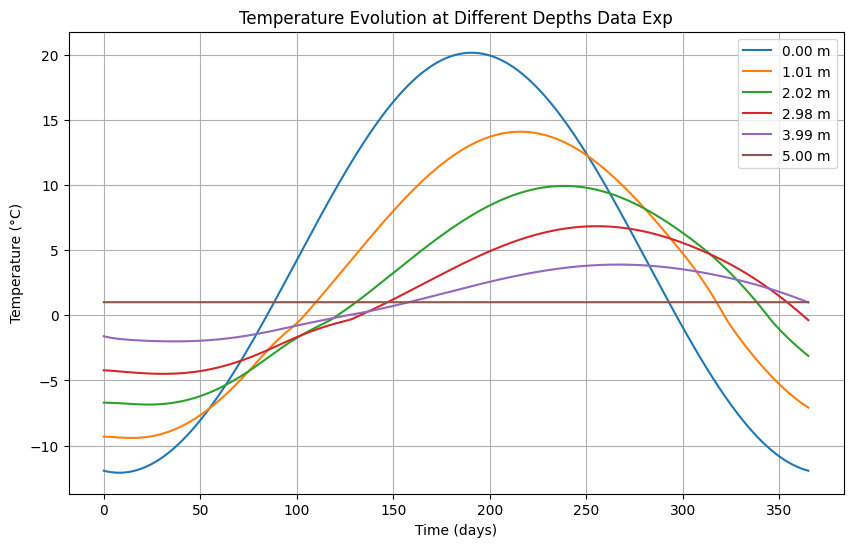

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 加载数据 ----------
data = np.load('fdm_results.npz')
x = data['x']               # 深度 (m), shape (Nx,)
t = data['t']               # 时间 (day), shape (Nt,)
T = data['T_field']         # 温度场 (°C), shape (Nx, Nt)

# ---------- 选择关注的深度（单位：米）----------
depths_of_interest = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]   # 可自定义

plt.figure(figsize=(10, 6))
for d in depths_of_interest:
    # 找到与目标深度最接近的网格索引
    idx = np.argmin(np.abs(x - d))
    actual_depth = x[idx]
    plt.plot(t, T[idx, :], label=f'{actual_depth:.2f} m')

plt.xlabel('Time (days)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Evolution at Different Depths Data Exp')
plt.legend()
plt.grid(True)
plt.show()

# PINNs

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(40)

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.interpolate import RegularGridInterpolator

# -------------------- 参数配置 --------------------
params = {
    'L': 334,
    'C_i': 1.672,
    'C_l': 4.18,
    'lambda_i': 2.210e-6 * 8.64e4,
    'lambda_l': 0.465e-6 * 8.64e4,
    'lambda_f': 2e-6 * 8.64e4,
    'C_f': 1.6,
    'eta': 0.4,
    'b': 0.7,
    'T_nabla': -0.3
}

depths_of_interest = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
x_min, x_max = 0.0, 5.0
t_min, t_max = 0.0, 365.0

# -------------------- 辅助函数 --------------------
def boundary_temperature(t):
    return 4.03 + 16.11 * torch.sin(2 * np.pi * t / 365 - 1.709)

def initial_temperature(x):
    T0_surface = boundary_temperature(torch.tensor(0.0)).item()
    return T0_surface + (1.0 - T0_surface) / 5.0 * x

# -------------------- 残差网络 --------------------
class ResidualMLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.linears = nn.ModuleList()
        self.activations = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                self.activations.append(nn.Tanh())
        self.residual_proj = None
        if layers[0] != layers[-1]:
            self.residual_proj = nn.Linear(layers[0], layers[-1])

    def forward(self, x):
        identity = x
        for i, linear in enumerate(self.linears):
            x = linear(x)
            if i < len(self.linears) - 1:
                x = self.activations[i](x)
        if self.residual_proj is not None:
            identity = self.residual_proj(identity)
        return x + identity

# -------------------- PINN 模型 --------------------
class PINN_FreezingSoil(nn.Module):
    def __init__(self, layers, params, scale=200000.0):
        super().__init__()
        self.params = params
        self.scale = scale
        self.net = ResidualMLP(layers)
        self.x_mean = (x_min + x_max) / 2
        self.x_std = (x_max - x_min) / 2
        self.t_mean = (t_min + t_max) / 2
        self.t_std = (t_max - t_min) / 2

    def forward(self, x, t):
        x_norm = (x - self.x_mean) / self.x_std
        t_norm = (t - self.t_mean) / self.t_std
        X = torch.cat([x_norm, t_norm], dim=1)
        return self.net(X)

    def phi(self, T):
        T_nabla = self.params['T_nabla']
        b = self.params['b']
        eps = 1e-6
        T_safe = torch.where(torch.abs(T) < eps, torch.tensor(eps, device=T.device), T)
        k = 0.5
        step = torch.sigmoid(k * (T - T_nabla))
        phi_low = (abs(T_nabla) ** b) * (torch.abs(T_safe) ** (-b))
        phi = step * 1.0 + (1 - step) * phi_low
        return phi

    def theta_u(self, T):
        return self.params['eta'] * self.phi(T)

    def C_eff(self, T):
        eta = self.params['eta']
        C_f = self.params['C_f']
        C_l = self.params['C_l']
        C_i = self.params['C_i']
        phi = self.phi(T)
        return (1 - eta) * C_f + eta * (phi * C_l + (1 - phi) * C_i)

    def lambda_eff(self, T):
        eta = self.params['eta']
        lambda_f = self.params['lambda_f']
        lambda_l = self.params['lambda_l']
        lambda_i = self.params['lambda_i']
        phi = self.phi(T)
        return (1 - eta) * lambda_f + eta * (phi * lambda_l + (1 - phi) * lambda_i)

    def pde_residual(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)
        T = self.forward(x, t)

        T_t = torch.autograd.grad(T, t, grad_outputs=torch.ones_like(T),
                                   create_graph=True, retain_graph=True)[0]
        T_x = torch.autograd.grad(T, x, grad_outputs=torch.ones_like(T),
                                   create_graph=True, retain_graph=True)[0]
        T_xx = torch.autograd.grad(T_x, x, grad_outputs=torch.ones_like(T_x),
                                    create_graph=True, retain_graph=True)[0]

        C = self.C_eff(T)
        lambda_ = self.lambda_eff(T)

        theta = self.theta_u(T)
        dtheta_dT = torch.autograd.grad(theta, T, grad_outputs=torch.ones_like(theta),
                                         create_graph=True, retain_graph=True)[0]
        dtheta_dt = dtheta_dT * T_t

        lambda_x = torch.autograd.grad(lambda_, x, grad_outputs=torch.ones_like(lambda_),
                                        create_graph=True, retain_graph=True)[0]
        conduction = lambda_x * T_x + lambda_ * T_xx

        L = self.params['L']
        residual = C * T_t - conduction + L * dtheta_dt
        return residual / self.scale

# -------------------- 损失函数 --------------------
def compute_loss(model, x_f, t_f, x_upper, t_upper, T_upper,
                 x_lower, t_lower, T_lower, x_ic, t_ic, T_ic,
                 w_pde, w_upper, w_lower, w_ic):
    res = model.pde_residual(x_f, t_f)
    loss_pde = torch.mean(torch.where(torch.abs(res) < 1, 0.5 * res**2, torch.abs(res) - 0.5))

    T_upper_pred = model(x_upper, t_upper)
    loss_upper = torch.mean((T_upper_pred - T_upper)**2)
    T_lower_pred = model(x_lower, t_lower)
    loss_lower = torch.mean((T_lower_pred - T_lower)**2)
    T_ic_pred = model(x_ic, t_ic)
    loss_ic = torch.mean((T_ic_pred - T_ic)**2)

    total_loss = w_pde*loss_pde + w_upper*loss_upper + w_lower*loss_lower + w_ic*loss_ic
    return total_loss, loss_pde, loss_upper, loss_lower, loss_ic

# -------------------- 数据生成 --------------------
def generate_training_data(N_f, N_b, N_ic, device):
    t_upper = torch.rand(N_b, 1, device=device) * (t_max - t_min) + t_min
    x_upper = torch.zeros_like(t_upper)
    T_upper = boundary_temperature(t_upper)

    t_lower = torch.rand(N_b, 1, device=device) * (t_max - t_min) + t_min
    x_lower = torch.ones_like(t_lower) * x_max
    T_lower = torch.ones_like(t_lower) * 1.0

    x_ic = torch.rand(N_ic, 1, device=device) * (x_max - x_min) + x_min
    t_ic = torch.zeros_like(x_ic)
    T_ic = torch.tensor(initial_temperature(x_ic.cpu().numpy()).flatten(),
                        dtype=torch.float32, device=device).view(-1, 1)

    n_candidate = 100000
    x_candidate = torch.rand(n_candidate, 1, device=device) * (x_max - x_min) + x_min
    t_candidate = torch.rand(n_candidate, 1, device=device) * (t_max - t_min) + t_min
    T_estimate = torch.tensor(initial_temperature(x_candidate.cpu().numpy()).flatten(),
                              dtype=torch.float32, device=device).view(-1, 1)
    sigma = 2.0
    weight = torch.exp(-((T_estimate - params['T_nabla'])**2) / (2 * sigma**2))
    weight = weight.flatten()
    weight = weight / weight.sum()
    idx = torch.multinomial(weight, N_f, replacement=True)
    x_f = x_candidate[idx]
    t_f = t_candidate[idx]

    return (x_f, t_f, x_upper, t_upper, T_upper,
            x_lower, t_lower, T_lower, x_ic, t_ic, T_ic)

# -------------------- 加载 FDM 数据（仅后处理） --------------------
def load_fdm_data(filename='fdm_results.npz'):
    if not os.path.exists(filename):
        print(f"FDM数据文件 {filename} 不存在，无法对比。")
        return None, None, None
    data = np.load(filename)
    x_fdm = data['x']
    t_fdm = data['t']
    T_fdm = data['T_field']
    return x_fdm, t_fdm, T_fdm

# -------------------- 可视化对比 --------------------
def plot_comparison(model, x_plot, t_plot, T_fdm=None, save_path='pinn_vs_fdm.png'):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        X, T = np.meshgrid(x_plot, t_plot, indexing='ij')
        x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).to(device).view(-1, 1)
        t_tensor = torch.tensor(T.flatten(), dtype=torch.float32).to(device).view(-1, 1)
        T_pinn = model(x_tensor, t_tensor).cpu().numpy().reshape(X.shape)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    times = [0, 90, 180, 270, 365]
    for t_val in times:
        idx_t = np.argmin(np.abs(t_plot - t_val))
        axes[0, 0].plot(x_plot, T_pinn[:, idx_t], label=f't={t_val}d (PINN)')
        if T_fdm is not None:
            axes[0, 0].plot(x_plot, T_fdm[:, idx_t], '--', label=f't={t_val}d (FDM)')
    axes[0, 0].set_xlabel('Depth (m)')
    axes[0, 0].set_ylabel('Temperature (°C)')
    axes[0, 0].set_title('Temperature Profiles')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    for x_val in depths_of_interest:
        idx_x = np.argmin(np.abs(x_plot - x_val))
        axes[0, 1].plot(t_plot, T_pinn[idx_x, :], label=f'x={x_val}m (PINN)')
        if T_fdm is not None:
            axes[0, 1].plot(t_plot, T_fdm[idx_x, :], '--', label=f'x={x_val}m (FDM)')
    axes[0, 1].set_xlabel('Time (days)')
    axes[0, 1].set_ylabel('Temperature (°C)')
    axes[0, 1].set_title('Temperature Evolution')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    im1 = axes[0, 2].contourf(t_plot, x_plot, T_pinn, levels=30, cmap='RdBu_r')
    axes[0, 2].contour(t_plot, x_plot, T_pinn, levels=[params['T_nabla']], colors='k', linewidths=2)
    axes[0, 2].set_xlabel('Time (days)')
    axes[0, 2].set_ylabel('Depth (m)')
    axes[0, 2].set_title('PINNs Temperature Field')
    axes[0, 2].invert_yaxis()
    plt.colorbar(im1, ax=axes[0, 2])

    if T_fdm is not None:
        im2 = axes[1, 0].contourf(t_plot, x_plot, T_fdm, levels=30, cmap='RdBu_r')
        axes[1, 0].contour(t_plot, x_plot, T_fdm, levels=[params['T_nabla']], colors='k', linewidths=2)
        axes[1, 0].set_xlabel('Time (days)')
        axes[1, 0].set_ylabel('Depth (m)')
        axes[1, 0].set_title('FDM Temperature Field')
        axes[1, 0].invert_yaxis()
        plt.colorbar(im2, ax=axes[1, 0])

        error = np.abs(T_pinn - T_fdm)
        im3 = axes[1, 1].contourf(t_plot, x_plot, error, levels=30, cmap='hot')
        axes[1, 1].set_xlabel('Time (days)')
        axes[1, 1].set_ylabel('Depth (m)')
        axes[1, 1].set_title('Absolute Error |PINN - FDM|')
        axes[1, 1].invert_yaxis()
        plt.colorbar(im3, ax=axes[1, 1])

        freezing_pinn = np.zeros(len(t_plot))
        freezing_fdm = np.zeros(len(t_plot))
        for j in range(len(t_plot)):
            profile_pinn = T_pinn[:, j]
            profile_fdm = T_fdm[:, j]
            idx_pinn = np.where(profile_pinn <= params['T_nabla'])[0]
            idx_fdm = np.where(profile_fdm <= params['T_nabla'])[0]
            freezing_pinn[j] = x_plot[idx_pinn[0]] if len(idx_pinn) > 0 else x_max
            freezing_fdm[j] = x_plot[idx_fdm[0]] if len(idx_fdm) > 0 else x_max
        axes[1, 2].plot(t_plot, freezing_pinn, 'b-', label='PINNs')
        axes[1, 2].plot(t_plot, freezing_fdm, 'r--', label='FDM')
        axes[1, 2].set_xlabel('Time (days)')
        axes[1, 2].set_ylabel('Freezing front depth (m)')
        axes[1, 2].set_title('Freezing Front Evolution')
        axes[1, 2].invert_yaxis()
        axes[1, 2].legend()
        axes[1, 2].grid(True)
    else:
        freezing_pinn = np.zeros(len(t_plot))
        for j in range(len(t_plot)):
            profile = T_pinn[:, j]
            idx = np.where(profile <= params['T_nabla'])[0]
            freezing_pinn[j] = x_plot[idx[0]] if len(idx) > 0 else x_max
        axes[1, 2].plot(t_plot, freezing_pinn, 'b-')
        axes[1, 2].set_xlabel('Time (days)')
        axes[1, 2].set_ylabel('Freezing front depth (m)')
        axes[1, 2].set_title('Freezing Front Evolution (PINNs)')
        axes[1, 2].invert_yaxis()
        axes[1, 2].grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

# -------------------- 主训练函数（逐步增加 PDE 权重） --------------------
# -------------------- 主训练函数（w_pde从0开始，逐步增至很大） --------------------
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    layers = [2, 128,128,128, 1]
    scale = 200000.0
    model = PINN_FreezingSoil(layers, params, scale=scale).to(device)

    N_f = 20000
    N_b = 1000
    N_ic = 1000
    (x_f, t_f, x_upper, t_upper, T_upper,
     x_lower, t_lower, T_lower, x_ic, t_ic, T_ic) = generate_training_data(N_f, N_b, N_ic, device)

    # 固定边界/初始权重
    w_upper = 1.0
    w_lower = 1.0
    w_ic = 1.0

    # PDE 权重初始为0
    w_pde = 0.0
    target_w_pde = 1e4   # 目标最大值 1e5
    # 定义阶段：每 stage_steps 步后，w_pde 乘以 factor
    stage_steps = 10000
    factor = 10.0

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2000)

    n_epochs = 500000  # 总步数，确保足够覆盖多个阶段
    print("开始Adam训练（w_pde从0逐步增加）...")
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss, loss_pde, loss_upper, loss_lower, loss_ic = compute_loss(
            model, x_f, t_f, x_upper, t_upper, T_upper,
            x_lower, t_lower, T_lower, x_ic, t_ic, T_ic,
            w_pde=w_pde, w_upper=w_upper, w_lower=w_lower, w_ic=w_ic
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss)

        # 每 stage_steps 步更新一次 w_pde（从第一次非零开始）
        if (epoch + 1) % stage_steps == 0:
            if w_pde == 0.0:
                w_pde = 1e-4 # 第一次非零
                print(f">>> 第 {(epoch+1)//stage_steps} 阶段：PDE权重初始化为 {w_pde:.2e}")
            elif w_pde < target_w_pde:
                w_pde = min(w_pde * factor, target_w_pde)
                print(f">>> 第 {(epoch+1)//stage_steps} 阶段：PDE权重提升至 {w_pde:.2e}")

        if epoch % 1000 == 0:
            print(f"Epoch {epoch:5d}, Total Loss: {loss.item():.3e}, "
                  f"PDE: {loss_pde.item():.3e}, Upper: {loss_upper.item():.3e}, "
                  f"Lower: {loss_lower.item():.3e}, IC: {loss_ic.item():.3e}, w_pde={w_pde:.2e}")

    torch.save(model.state_dict(), 'pinn_freezing_soil_ramp_from0.pth')
    print("模型已保存至 pinn_freezing_soil_ramp_from0.pth")


    # 与FDM对比
    x_fdm, t_fdm, T_fdm_raw = load_fdm_data('fdm_results.npz')
    T_fdm_interp = None
    if x_fdm is not None:
        x_plot = np.linspace(x_min, x_max, 100)
        t_plot = np.linspace(t_min, t_max, 365)
        interp = RegularGridInterpolator((x_fdm, t_fdm), T_fdm_raw, bounds_error=False, fill_value=None)
        X, T = np.meshgrid(x_plot, t_plot, indexing='ij')
        T_fdm_interp = interp((X, T))
        print("已加载 FDM 数据并插值。")
    else:
        x_plot = np.linspace(x_min, x_max, 100)
        t_plot = np.linspace(t_min, t_max, 365)

    plot_comparison(model, x_plot, t_plot, T_fdm_interp, save_path='pinn_vs_fdm_ramp_pde.png')

Using device: cuda
开始Adam训练（w_pde从0逐步增加）...
Epoch     0, Total Loss: 1.921e+02, PDE: 6.088e-13, Upper: 1.447e+02, Lower: 3.929e+00, IC: 4.354e+01, w_pde=0.00e+00
Epoch  1000, Total Loss: 2.934e+01, PDE: 5.940e-04, Upper: 2.855e+01, Lower: 5.703e-01, IC: 2.210e-01, w_pde=0.00e+00
Epoch  2000, Total Loss: 9.644e+00, PDE: 1.435e-03, Upper: 8.692e+00, Lower: 9.128e-01, IC: 3.987e-02, w_pde=0.00e+00
Epoch  3000, Total Loss: 4.795e+00, PDE: 6.410e-03, Upper: 4.218e+00, Lower: 5.676e-01, IC: 9.768e-03, w_pde=0.00e+00
Epoch  4000, Total Loss: 2.338e+00, PDE: 2.195e-02, Upper: 2.032e+00, Lower: 3.032e-01, IC: 2.535e-03, w_pde=0.00e+00
Epoch  5000, Total Loss: 9.482e-01, PDE: 5.514e-04, Upper: 8.060e-01, Lower: 1.416e-01, IC: 6.419e-04, w_pde=0.00e+00
Epoch  6000, Total Loss: 7.136e-02, PDE: 1.653e-04, Upper: 5.714e-02, Lower: 1.399e-02, IC: 2.243e-04, w_pde=0.00e+00
Epoch  7000, Total Loss: 8.091e-04, PDE: 5.455e-05, Upper: 4.790e-04, Lower: 1.689e-04, IC: 1.613e-04, w_pde=0.00e+00
Epoch  8000,

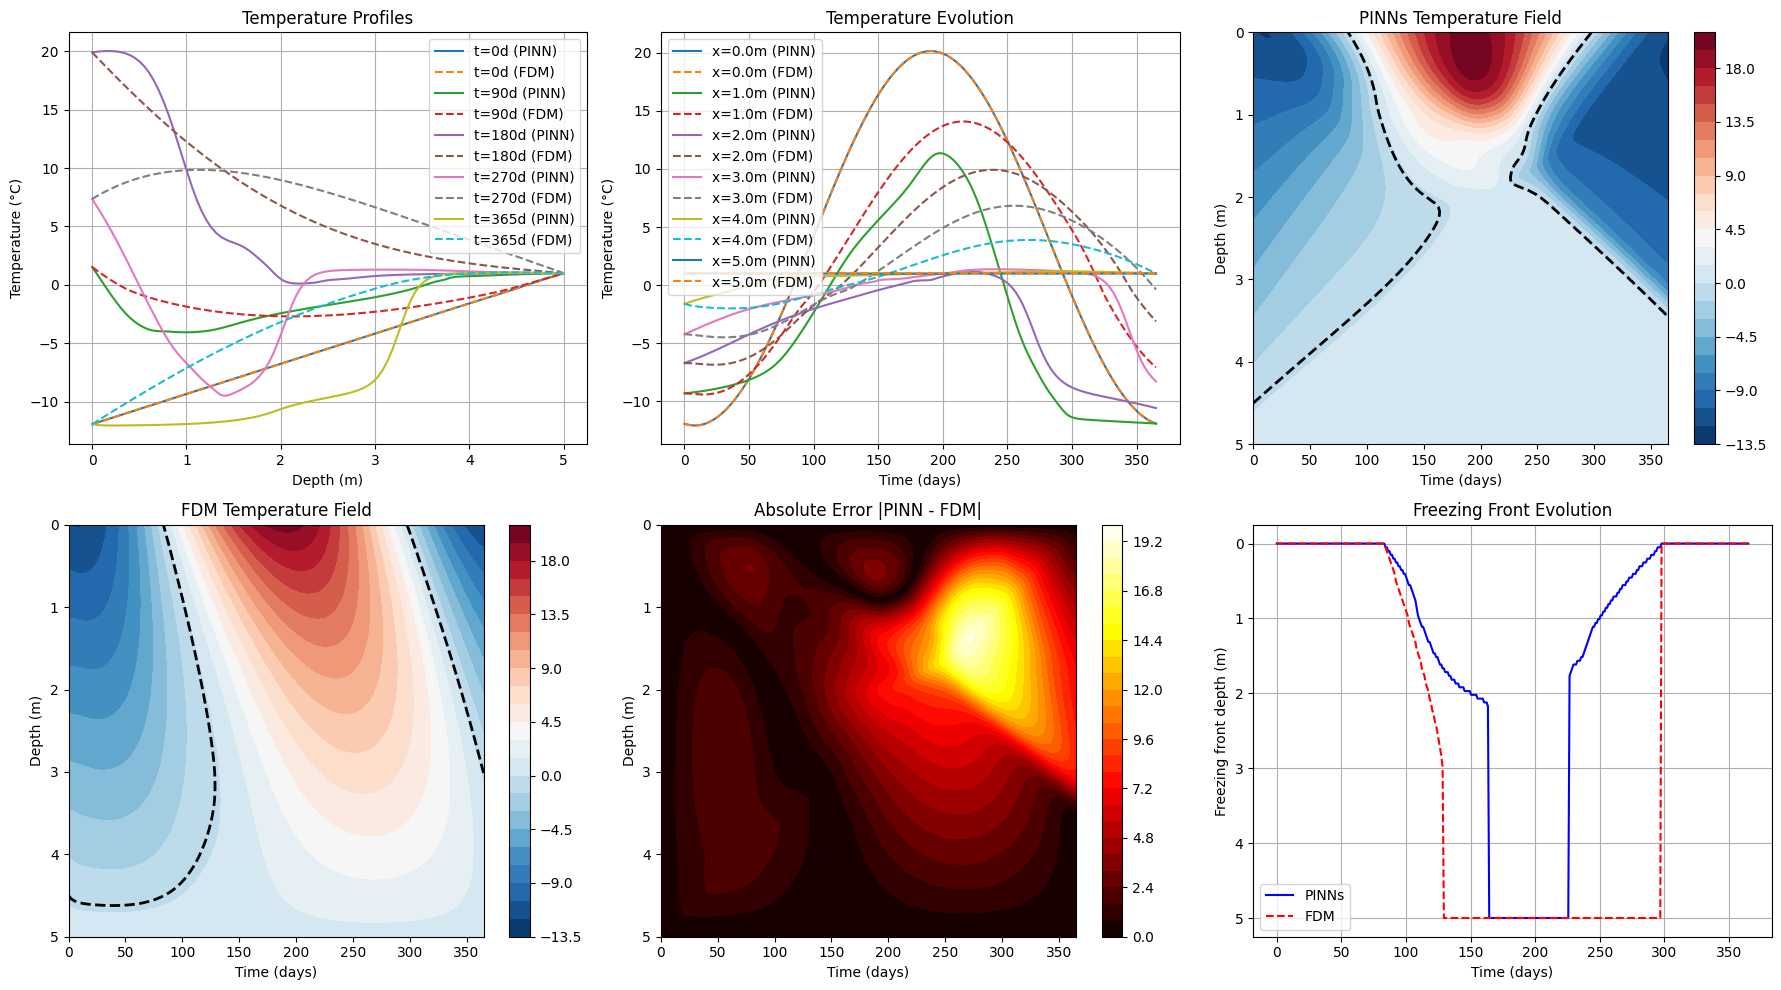

In [33]:
if __name__ == '__main__':
    main()